In [27]:
!pip install tensorflow tensorflowjs -q

In [28]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import pandas as pd
import numpy as np
import os
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflowjs as tfjs

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from google.colab import files

# Set seed untuk reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [29]:
# =========================================================
# LOAD DATA & PREPROCESSING
# =========================================================
df = pd.read_csv("/content/dataset_c_whatif.csv")

print(f"Shape awal: {df.shape}")
print(f"\nDistribusi label:")
print(df['label_whatif'].value_counts())

# Hapus kolom yang menyebabkan data leakage
FORBIDDEN_COLS = ["etr_after_purchase", "cashflow_after_purchase",
                  "months_to_recover", "current_etr_trend"]
df = df.drop(columns=[c for c in FORBIDDEN_COLS if c in df.columns], errors='ignore')

# Pisahkan Fitur & Label
X = df.drop(columns=["label_whatif", "persona_id"], errors='ignore')
y = df["label_whatif"]

# One-Hot Encoding untuk kolom kategorikal
X = pd.get_dummies(X, drop_first=False)
final_feature_columns = X.columns.tolist()
print(f"\nJumlah fitur setelah encoding: {len(final_feature_columns)}")

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode label
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_.tolist()
print(f"Kelas: {class_names}")

# Stratified Split - menjaga proporsi kelas di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nDistribusi kelas di Train set: {dict(zip(class_names, np.bincount(y_train)))}")
print(f"Distribusi kelas di Test set:  {dict(zip(class_names, np.bincount(y_test)))}")

Shape awal: (10000, 28)

Distribusi label:
label_whatif
just_buy       7364
buy_careful    1953
dont_buy        683
Name: count, dtype: int64

Jumlah fitur setelah encoding: 38
Kelas: ['buy_careful', 'dont_buy', 'just_buy']

Distribusi kelas di Train set: {'buy_careful': np.int64(1563), 'dont_buy': np.int64(546), 'just_buy': np.int64(5891)}
Distribusi kelas di Test set:  {'buy_careful': np.int64(390), 'dont_buy': np.int64(137), 'just_buy': np.int64(1473)}


In [30]:
# =========================================================
# PERSIAPAN LABEL & BOBOT KELAS
# =========================================================
y_train_ohe = tf.keras.utils.to_categorical(y_train)
y_test_ohe  = tf.keras.utils.to_categorical(y_test)

# Hitung class weight secara otomatis berdasarkan distribusi data
cw_values = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_train)
balanced_weights = {i: float(w) for i, w in enumerate(cw_values)}

print("Class weights yang dihitung secara otomatis:")
for i, name in enumerate(class_names):
    print(f"  {i} ({name}): {balanced_weights[i]:.4f}")

Class weights yang dihitung secara otomatis:
  0 (buy_careful): 1.7061
  1 (dont_buy): 4.8840
  2 (just_buy): 0.4527


In [31]:
# =========================================================
# ARSITEKTUR MODEL - REGULARIZED RESIDUAL NETWORK
# =========================================================

n_features = X_train.shape[1]
n_classes = len(class_names)
L2 = 1e-3  # Regularization strength

inputs = tf.keras.layers.Input(shape=(n_features,))

# --- Block 1: Proyeksi Awal ---
x = tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(L2))(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.30)(x)  # Dropout ditingkatkan ke 30%

# --- Residual Block ---
res = x
x = tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(L2))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.30)(x)
x = tf.keras.layers.Add()([x, res])  # Skip connection

# --- Block 2: Penyempitan ---
x = tf.keras.layers.Dense(32, kernel_regularizer=tf.keras.regularizers.l2(L2))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.20)(x)

# --- Output ---
outputs = tf.keras.layers.Dense(n_classes, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # LR diturunkan
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 64)        │      2,496 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_30[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64)        │          0 │ activation_7[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 64)        │      4,160 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_31[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64)        │          0 │ activation_8[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64)        │          0 │ dropout_15[0][0], │
│                     │                   │            │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │      2,080 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_32[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 32)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 32)        │          0 │ activation_9[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 3)         │         99 │ dropout_16[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,475 (37.01 KB)

 Trainable params: 9,155 (35.76 KB)

 Non-trainable params: 320 (1.25 KB)

In [32]:
# =========================================================
# TRAINING DENGAN CALLBACKS
# =========================================================
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("\nMemulai Training...")
history = model.fit(
    X_train, y_train_ohe,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, y_test_ohe),
    class_weight=balanced_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Memulai Training...
Epoch 1/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4066 - loss: 1.3315 - val_accuracy: 0.5695 - val_loss: 1.0999 - learning_rate: 5.0000e-04
Epoch 2/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5968 - loss: 1.0354 - val_accuracy: 0.7610 - val_loss: 0.8604 - learning_rate: 5.0000e-04
Epoch 3/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6889 - loss: 0.9076 - val_accuracy: 0.7970 - val_loss: 0.7414 - learning_rate: 5.0000e-04
Epoch 4/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7416 - loss: 0.8208 - val_accuracy: 0.8220 - val_loss: 0.6691 - learning_rate: 5.0000e-04
Epoch 5/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7615 - loss: 0.7755 - val_accuracy: 0.8385 - val_loss: 0.6234 - learning_rate: 5.0000e-04
Epoch 6/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7845 - loss: 0.7325 - val_accuracy: 0.8490 - val_loss: 0.5896 - learning_rate: 5.0000e-04
Epoch 7/150
125/125 ━━━━━━━━━━━━━━━━

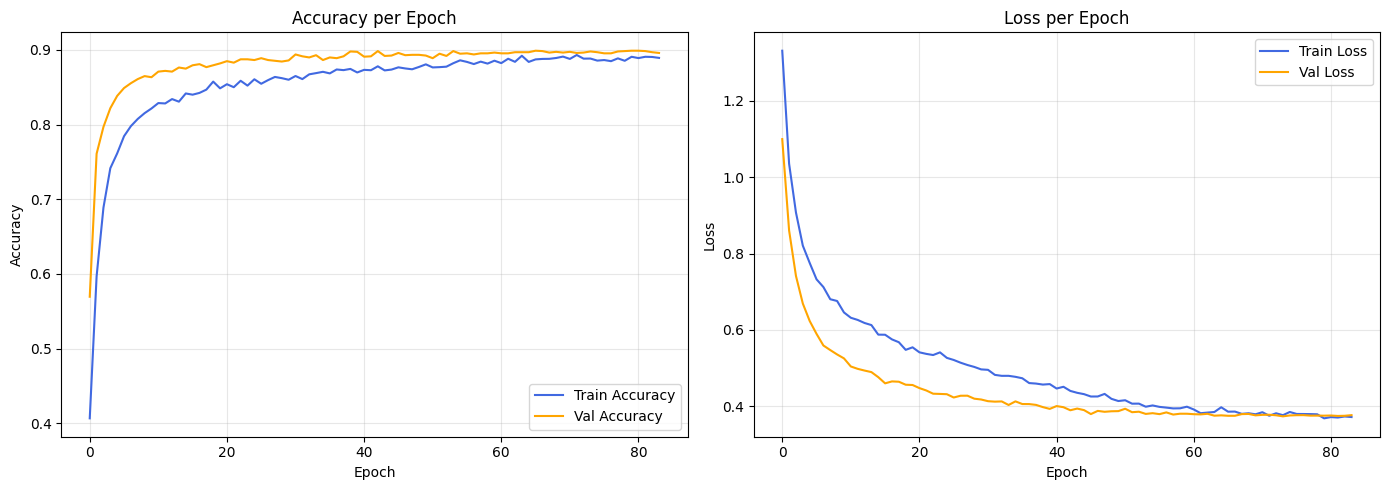

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Train Accuracy : 0.8894
Val Accuracy   : 0.8960
Overfitting Gap: -0.0066  (target < 0.03)
Epochs berjalan: 84

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 buy_careful       0.75      0.73      0.74       390
    dont_buy       0.81      0.93      0.87       137
    just_buy       0.95      0.94      0.94      1473

    accuracy                           0.90      2000
   macro avg       0.84      0.87      0.85      2000
weighted avg       0.90      0.90      0.90      2000



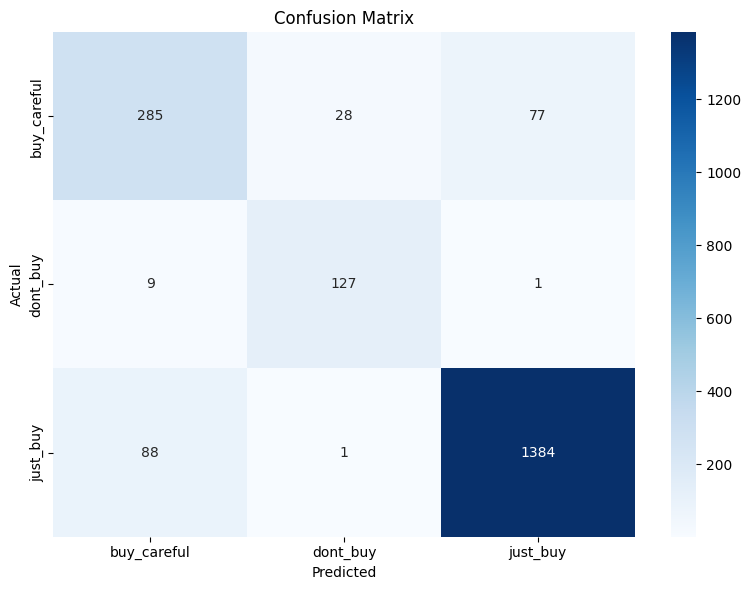

In [33]:
# =========================================================
# VISUALISASI & EVALUASI
# =========================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Akurasi
ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='royalblue')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax[0].set_title('Accuracy per Epoch')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Loss
ax[1].plot(history.history['loss'], label='Train Loss', color='royalblue')
ax[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
ax[1].set_title('Loss per Epoch')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Evaluasi Metrik ---
y_pred_probs   = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

train_acc = history.history['accuracy'][-1]
val_acc   = history.history['val_accuracy'][-1]
print(f"\nTrain Accuracy : {train_acc:.4f}")
print(f"Val Accuracy   : {val_acc:.4f}")
print(f"Overfitting Gap: {train_acc - val_acc:.4f}  (target < 0.03)")
print(f"Epochs berjalan: {len(history.history['accuracy'])}")

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [34]:
# =========================================================
# EXPORT MODEL & METADATA
# =========================================================
tfjs_path = "tfjs_model_whatif"
tfjs.converters.save_keras_model(model, tfjs_path)

metadata = {
    "feature_columns": final_feature_columns,
    "class_names": class_names,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_variance": scaler.var_.tolist(),
    "scaler_scale": scaler.scale_.tolist()
}

with open(f"{tfjs_path}/metadata.json", "w") as f:
    json.dump(metadata, f)

print(f"Model disimpan ke: {tfjs_path}/")

failed to lookup keras version from the file,
    this is likely a weight only file
Model disimpan ke: tfjs_model_whatif/


In [35]:
# =========================================================
# DOWNLOAD
# =========================================================
!zip -r model_whatif_tfjs.zip {tfjs_path}
files.download("model_whatif_tfjs.zip")
print("\nSelesai!")

  adding: tfjs_model_whatif/ (stored 0%)
  adding: tfjs_model_whatif/metadata.json (deflated 53%)
  adding: tfjs_model_whatif/model.json (deflated 89%)
  adding: tfjs_model_whatif/group1-shard1of1.bin (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Selesai!
